## Low-light-denoising-4x-Super-Resolution
Roll: 22f3002680

In [ ]:
!pip install -q huggingface_hub

In [ ]:
import os, re, glob, random, math, time, urllib.request
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt


SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)
if DEVICE.type == 'cuda':
    print(torch.cuda.get_device_name(0))

device: cuda
Tesla T4


In [ ]:
DATA_ROOT = '/kaggle/input/competitions/dlp-26t2-nppe3/archive'

TRAIN_LR_DIR = f'{DATA_ROOT}/train/train'
TRAIN_HR_DIR = f'{DATA_ROOT}/train/gt'
VAL_LR_DIR   = f'{DATA_ROOT}/val/val'
VAL_HR_DIR   = f'{DATA_ROOT}/val/gt'
TEST_DIR     = f'{DATA_ROOT}/test'

SCALE       = 4
BATCH_SIZE  = 8
NUM_WORKERS = 2
EPOCHS      = 40
WARMUP_EPOCHS = 2
LR_RATE     = 1e-4
WEIGHT_DECAY = 1e-4
EMA_DECAY   = 0.995

PATCH_SCHEDULE = [
    (80,  128, 0.00, 0.50),
    (112, 176, 0.50, 1.00),
]
GRAD_LOSS_WEIGHT = 0.05
MSE_FINETUNE_FRAC = 0.75

CKPT_DIR  = '/kaggle/working/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
BEST_CKPT = f'{CKPT_DIR}/best_model_v4_1.pth'


PRETRAINED_DIR = '/kaggle/working/pretrained'
os.makedirs(PRETRAINED_DIR, exist_ok=True)
PRETRAINED_URL = 'https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.1/RealESRNet_x4plus.pth'
PRETRAINED_PATH = f'{PRETRAINED_DIR}/RealESRNet_x4plus.pth'

# Hugging Face push settings
HF_TOKEN   = "" #token hidden for form submission
HF_REPO_ID = "somsubhra04/lowlight-denoise-sr4x"
PUSH_TO_HF = True

In [ ]:
def extract_id(fname):
    m = re.findall(r'(\d+)', fname)
    return m[-1] if m else fname

def list_id_map(folder):
    d = {}
    for f in os.listdir(folder):
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            d[extract_id(f)] = os.path.join(folder, f)
    return d

train_lr_map = list_id_map(TRAIN_LR_DIR)
train_hr_map = list_id_map(TRAIN_HR_DIR)
val_lr_map   = list_id_map(VAL_LR_DIR)
val_hr_map   = list_id_map(VAL_HR_DIR)

train_ids = sorted(set(train_lr_map) & set(train_hr_map))
val_ids   = sorted(set(val_lr_map) & set(val_hr_map))

print(f'train pairs: {len(train_ids)} | val pairs: {len(val_ids)}')

# sanity check: scale factor + size consistency
lr0 = Image.open(train_lr_map[train_ids[0]])
hr0 = Image.open(train_hr_map[train_ids[0]])
print('sample LR size:', lr0.size, '| sample HR size:', hr0.size)
print('inferred scale factor:', hr0.size[0] / lr0.size[0], hr0.size[1] / lr0.size[1])

from collections import Counter
lr_sizes = Counter(Image.open(train_lr_map[i]).size for i in train_ids[:200])
hr_sizes = Counter(Image.open(train_hr_map[i]).size for i in train_ids[:200])
print('LR size distribution (sample of 200):', lr_sizes)
print('HR size distribution (sample of 200):', hr_sizes)

train pairs: 1105 | val pairs: 267
sample LR size: (256, 160) | sample HR size: (1024, 640)
inferred scale factor: 4.0 4.0
LR size distribution (sample of 200): Counter({(256, 160): 200})
HR size distribution (sample of 200): Counter({(1024, 640): 200})


In [ ]:
class SRDataset(Dataset):
    def __init__(self, ids, lr_map, hr_map, patch_h, patch_w, scale=SCALE, train=True):
        self.ids, self.lr_map, self.hr_map = ids, lr_map, hr_map
        self.patch_h, self.patch_w, self.scale, self.train = patch_h, patch_w, scale, train

    def __len__(self): return len(self.ids)

    @staticmethod
    def _load(path):
        return np.array(Image.open(path).convert('RGB'), dtype=np.float32) / 255.0

    def __getitem__(self, idx):
        _id = self.ids[idx]
        lr = self._load(self.lr_map[_id]); hr = self._load(self.hr_map[_id])
        h, w, _ = lr.shape
        ph, pw = self.patch_h, self.patch_w

        if self.train:
            top  = random.randint(0, max(0, h - ph))
            left = random.randint(0, max(0, w - pw))
            lr_p = lr[top:top+ph, left:left+pw]
            hr_p = hr[top*self.scale:(top+ph)*self.scale, left*self.scale:(left+pw)*self.scale]
            if random.random() < 0.5:
                lr_p = np.fliplr(lr_p).copy(); hr_p = np.fliplr(hr_p).copy()
            if random.random() < 0.5:
                lr_p = np.flipud(lr_p).copy(); hr_p = np.flipud(hr_p).copy()
            rot_k = random.choice([0, 2])
            if rot_k > 0:
                lr_p = np.rot90(lr_p, rot_k).copy(); hr_p = np.rot90(hr_p, rot_k).copy()

        else:
            lr_p, hr_p = lr, hr

        return (torch.from_numpy(lr_p).permute(2,0,1).float(),
                torch.from_numpy(hr_p).permute(2,0,1).float(), _id)

train_ds = SRDataset(train_ids, train_lr_map, train_hr_map, patch_h=48, patch_w=64, train=True)
val_ds = SRDataset(val_ids, val_lr_map, val_hr_map, patch_h=None, patch_w=None, train=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

In [ ]:
# to check if brightness is the problem
'''sample_ids = train_ids[:100]
lr_means, hr_means = [], []
for i in sample_ids:
    lr = np.array(Image.open(train_lr_map[i]).convert('RGB'), dtype=np.float32) / 255.0
    hr = np.array(Image.open(train_hr_map[i]).convert('RGB'), dtype=np.float32) / 255.0
    lr_means.append(lr.mean()); hr_means.append(hr.mean())

print(f'LR mean brightness: {np.mean(lr_means):.4f}')
print(f'HR mean brightness: {np.mean(hr_means):.4f}')
print(f'ratio (HR/LR): {np.mean(hr_means)/np.mean(lr_means):.2f}x')

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for j, i in enumerate(sample_ids[:4]):
    lr = Image.open(train_lr_map[i]); hr = Image.open(train_hr_map[i])
    axes[0, j].imshow(lr); axes[0, j].set_title(f'LR {i}'); axes[0, j].axis('off')
    axes[1, j].imshow(hr); axes[1, j].set_title(f'HR {i}'); axes[1, j].axis('off')
plt.tight_layout(); plt.show()
'''

#bottleneck isn't exposure, it's noise removal and detail recovery at 4x. That redirects effort towards
#Verifying the noise characteristics instead
'''sample_ids = train_ids[:20]
residual_stds = []
for i in sample_ids:
    lr = Image.open(train_lr_map[i]).convert('RGB')
    hr = np.array(Image.open(train_hr_map[i]).convert('RGB'), dtype=np.float32) / 255.0
    lr_up = np.array(lr.resize(hr.shape[1::-1], Image.BICUBIC), dtype=np.float32) / 255.0
    residual = hr - lr_up
    residual_stds.append(residual.std())

print(f'mean residual std (noise+detail gap): {np.mean(residual_stds):.4f}')

fig, axes = plt.subplots(1, 3, figsize=(12,4))
i = sample_ids[0]
lr_up = np.array(Image.open(train_lr_map[i]).convert('RGB').resize((1024,640), Image.BICUBIC))
hr = np.array(Image.open(train_hr_map[i]).convert('RGB'))
axes[0].imshow(lr_up); axes[0].set_title('LR bicubic x4'); axes[0].axis('off')
axes[1].imshow(hr); axes[1].set_title('HR ground truth'); axes[1].axis('off')
axes[2].imshow(np.abs(hr.astype(int) - lr_up.astype(int)).astype(np.uint8)); axes[2].set_title('|residual|'); axes[2].axis('off')
plt.tight_layout(); plt.show()'''

"sample_ids = train_ids[:20]\nresidual_stds = []\nfor i in sample_ids:\n    lr = Image.open(train_lr_map[i]).convert('RGB')\n    hr = np.array(Image.open(train_hr_map[i]).convert('RGB'), dtype=np.float32) / 255.0\n    lr_up = np.array(lr.resize(hr.shape[1::-1], Image.BICUBIC), dtype=np.float32) / 255.0\n    residual = hr - lr_up\n    residual_stds.append(residual.std())\n\nprint(f'mean residual std (noise+detail gap): {np.mean(residual_stds):.4f}')\n\nfig, axes = plt.subplots(1, 3, figsize=(12,4))\ni = sample_ids[0]\nlr_up = np.array(Image.open(train_lr_map[i]).convert('RGB').resize((1024,640), Image.BICUBIC))\nhr = np.array(Image.open(train_hr_map[i]).convert('RGB'))\naxes[0].imshow(lr_up); axes[0].set_title('LR bicubic x4'); axes[0].axis('off')\naxes[1].imshow(hr); axes[1].set_title('HR ground truth'); axes[1].axis('off')\naxes[2].imshow(np.abs(hr.astype(int) - lr_up.astype(int)).astype(np.uint8)); axes[2].set_title('|residual|'); axes[2].axis('off')\nplt.tight_layout(); plt.show()"

In [ ]:
# to check if a straight bicubic downsample of HR matches the actual LR closely?
'''sample_ids = train_ids[:20]
kernel_residuals = []
for i in sample_ids:
    hr = Image.open(train_hr_map[i]).convert('RGB')
    lr_actual = np.array(Image.open(train_lr_map[i]).convert('RGB'), dtype=np.float32) / 255.0
    lr_bicubic = np.array(hr.resize((256, 160), Image.BICUBIC), dtype=np.float32) / 255.0
    kernel_residuals.append((lr_actual - lr_bicubic).std())

print(f'LR vs bicubic-downsampled-HR residual std: {np.mean(kernel_residuals):.4f}')'''

"sample_ids = train_ids[:20]\nkernel_residuals = []\nfor i in sample_ids:\n    hr = Image.open(train_hr_map[i]).convert('RGB')\n    lr_actual = np.array(Image.open(train_lr_map[i]).convert('RGB'), dtype=np.float32) / 255.0\n    lr_bicubic = np.array(hr.resize((256, 160), Image.BICUBIC), dtype=np.float32) / 255.0\n    kernel_residuals.append((lr_actual - lr_bicubic).std())\n\nprint(f'LR vs bicubic-downsampled-HR residual std: {np.mean(kernel_residuals):.4f}')"

In [ ]:
def make_layer(basic_block, num_basic_block, **kwarg):
    return nn.Sequential(*[basic_block(**kwarg) for _ in range(num_basic_block)])

class ResidualDenseBlock(nn.Module):
    def __init__(self, num_feat=64, num_grow_ch=32):
        super().__init__()
        self.conv1 = nn.Conv2d(num_feat, num_grow_ch, 3, 1, 1)
        self.conv2 = nn.Conv2d(num_feat + num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv3 = nn.Conv2d(num_feat + 2 * num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv4 = nn.Conv2d(num_feat + 3 * num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv5 = nn.Conv2d(num_feat + 4 * num_grow_ch, num_feat, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x5 * 0.2 + x

class RRDB(nn.Module):
    def __init__(self, num_feat, num_grow_ch=32):
        super().__init__()
        self.rdb1 = ResidualDenseBlock(num_feat, num_grow_ch)
        self.rdb2 = ResidualDenseBlock(num_feat, num_grow_ch)
        self.rdb3 = ResidualDenseBlock(num_feat, num_grow_ch)

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        return out * 0.2 + x

class RRDBNet(nn.Module):
    def __init__(self, num_in_ch=3, num_out_ch=3, scale=4, num_feat=64, num_block=23, num_grow_ch=32):
        super().__init__()
        self.scale = scale
        self.conv_first = nn.Conv2d(num_in_ch, num_feat, 3, 1, 1)
        self.body = make_layer(RRDB, num_block, num_feat=num_feat, num_grow_ch=num_grow_ch)
        self.conv_body = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_up1 = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_up2 = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_hr = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_last = nn.Conv2d(num_feat, num_out_ch, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        feat = self.conv_first(x)
        body_feat = self.conv_body(self.body(feat))
        feat = feat + body_feat
        feat = self.lrelu(self.conv_up1(F.interpolate(feat, scale_factor=2, mode='nearest')))
        feat = self.lrelu(self.conv_up2(F.interpolate(feat, scale_factor=2, mode='nearest')))
        out = self.conv_last(self.lrelu(self.conv_hr(feat)))
        return out

model = RRDBNet(num_in_ch=3, num_out_ch=3, scale=SCALE, num_feat=64, num_block=23, num_grow_ch=32).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'{n_params:.2f}M parameters')

16.70M parameters


In [ ]:
#Load pretrained Real-ESRGAN x4plus weights
if not os.path.exists(PRETRAINED_PATH):
    print('downloading pretrained Real-ESRGAN x4plus weights...')
    urllib.request.urlretrieve(PRETRAINED_URL, PRETRAINED_PATH)
print('checkpoint size (MB):', round(os.path.getsize(PRETRAINED_PATH) / 1e6, 1))

ckpt = torch.load(PRETRAINED_PATH, map_location='cpu')
state_dict = ckpt.get('params_ema', ckpt.get('params', ckpt))

missing, unexpected = model.load_state_dict(state_dict, strict=False)
print('missing keys:', missing)
print('unexpected keys:', unexpected)
print('pretrained weights loaded.' if not missing and not unexpected else 'loaded with some mismatches.')


downloading pretrained Real-ESRGAN x4plus weights...
checkpoint size (MB): 67.0
missing keys: []
unexpected keys: []
pretrained weights loaded.


In [ ]:
def charbonnier_loss(pred, target, eps=1e-3):
    return torch.mean(torch.sqrt((pred - target) ** 2 + eps ** 2))

def psnr(pred, target, max_val=1.0):
    mse = F.mse_loss(pred, target)
    if mse.item() == 0:
        return torch.tensor(100.0)
    return 10 * torch.log10(max_val ** 2 / mse)

def sobel_grad_loss(pred, target):
    kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32, device=pred.device).view(1,1,3,3)
    ky = kx.transpose(2,3)
    kx = kx.repeat(3,1,1,1); ky = ky.repeat(3,1,1,1)
    gx_p = F.conv2d(pred, kx, padding=1, groups=3); gy_p = F.conv2d(pred, ky, padding=1, groups=3)
    gx_t = F.conv2d(target, kx, padding=1, groups=3); gy_t = F.conv2d(target, ky, padding=1, groups=3)
    return F.l1_loss(gx_p, gx_t) + F.l1_loss(gy_p, gy_t)

In [ ]:
def set_trainable(model, warmup):
    tail = ('conv_up1', 'conv_up2', 'conv_hr', 'conv_last')
    for name, p in model.named_parameters():
        p.requires_grad = any(name.startswith(t) for t in tail) if warmup else True

class ModelEMA:
    def __init__(self, model, decay=EMA_DECAY):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if v.dtype.is_floating_point:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)
            else:
                self.shadow[k] = v.detach().clone()

def patch_for_epoch(epoch, total_epochs):
    frac = epoch / total_epochs
    for ph, pw, start, end in PATCH_SCHEDULE:
        if start <= frac < end:
            return ph, pw
    return PATCH_SCHEDULE[-1][0], PATCH_SCHEDULE[-1][1]

def build_optimizer(model, base_lr):
    tail = ('conv_up1', 'conv_up2', 'conv_hr', 'conv_last')
    body_params, tail_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad: continue
        (tail_params if any(name.startswith(t) for t in tail) else body_params).append(p)
    groups = [{'params': tail_params, 'lr': base_lr}]
    if body_params:
        groups.append({'params': body_params, 'lr': base_lr * 0.1})
    return torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)

ema = ModelEMA(model)
ema_model = RRDBNet(num_in_ch=3, num_out_ch=3, scale=SCALE, num_feat=64, num_block=23, num_grow_ch=32).to(DEVICE)
scaler = torch.amp.GradScaler('cuda')
best_psnr, history = 0.0, {'train_loss': [], 'val_psnr': []}
optimizer, scheduler, current_patch = None, None, None

for epoch in range(EPOCHS):
    warmup  = epoch < WARMUP_EPOCHS
    use_mse = epoch >= int(EPOCHS * MSE_FINETUNE_FRAC)
    target_patch = patch_for_epoch(epoch, EPOCHS)

    if target_patch != current_patch:
        current_patch = target_patch
        ph, pw = current_patch
        batch = max(2, int(BATCH_SIZE * (96 / max(ph, pw))))
        train_ds = SRDataset(train_ids, train_lr_map, train_hr_map, patch_h=ph, patch_w=pw, train=True)
        train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True,
                                   num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
        print(f'  -> patch={ph}x{pw}, batch={batch}')

    if epoch == 0 or epoch == WARMUP_EPOCHS:
        set_trainable(model, warmup)
        optimizer = build_optimizer(model, LR_RATE)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - epoch)

    model.train(); epoch_loss = 0.0; t0 = time.time()
    for lr_img, hr_img, _ in train_loader:
        lr_img = lr_img.to(DEVICE, non_blocking=True); hr_img = hr_img.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            pred = model(lr_img)
            if use_mse:
                loss = F.mse_loss(pred, hr_img)
            else:
                loss = charbonnier_loss(pred, hr_img) + GRAD_LOSS_WEIGHT * sobel_grad_loss(pred, hr_img)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), 1.0)
        scaler.step(optimizer); scaler.update()
        ema.update(model)
        epoch_loss += loss.item()
    scheduler.step(); epoch_loss /= len(train_loader)

    ema_model.load_state_dict(ema.shadow); ema_model.eval()
    val_psnrs = []
    with torch.no_grad():
        for lr_img, hr_img, _ in val_loader:
            lr_img = lr_img.to(DEVICE); hr_img = hr_img.to(DEVICE)
            with torch.amp.autocast('cuda'):
                pred = ema_model(lr_img).clamp(0, 1)
            val_psnrs.append(psnr(pred, hr_img).item())
    val_psnr = float(np.mean(val_psnrs))
    history['train_loss'].append(epoch_loss); history['val_psnr'].append(val_psnr)
    tag = ' [warmup]' if warmup else (' [mse-ft]' if use_mse else '')
    print(f'Epoch {epoch+1:03d}/{EPOCHS} | loss {epoch_loss:.4f} | EMA val PSNR {val_psnr:.3f} dB | {time.time()-t0:.1f}s{tag}')

    if val_psnr > best_psnr:
        best_psnr = val_psnr
        torch.save({'model_state': ema.shadow, 'raw_state': model.state_dict(),
                    'epoch': epoch, 'val_psnr': val_psnr}, BEST_CKPT)
        print(f'  -> new best checkpoint saved ({best_psnr:.3f} dB)')

print('Fine-tuning finished. Best EMA val PSNR:', best_psnr)

  -> patch=80x128, batch=6
Epoch 001/40 | loss 0.0132 | EMA val PSNR 38.289 dB | 129.0s [warmup]
  -> new best checkpoint saved (38.289 dB)
Epoch 002/40 | loss 0.0130 | EMA val PSNR 38.707 dB | 132.8s [warmup]
  -> new best checkpoint saved (38.707 dB)
Epoch 003/40 | loss 0.0123 | EMA val PSNR 39.200 dB | 237.7s
  -> new best checkpoint saved (39.200 dB)
Epoch 004/40 | loss 0.0124 | EMA val PSNR 39.359 dB | 237.1s
  -> new best checkpoint saved (39.359 dB)
Epoch 005/40 | loss 0.0120 | EMA val PSNR 39.420 dB | 237.5s
  -> new best checkpoint saved (39.420 dB)
Epoch 006/40 | loss 0.0122 | EMA val PSNR 39.447 dB | 237.4s
  -> new best checkpoint saved (39.447 dB)
Epoch 007/40 | loss 0.0121 | EMA val PSNR 39.467 dB | 237.6s
  -> new best checkpoint saved (39.467 dB)
Epoch 008/40 | loss 0.0122 | EMA val PSNR 39.477 dB | 237.4s
  -> new best checkpoint saved (39.477 dB)
Epoch 009/40 | loss 0.0120 | EMA val PSNR 39.484 dB | 237.5s
  -> new best checkpoint saved (39.484 dB)
Epoch 010/40 | loss

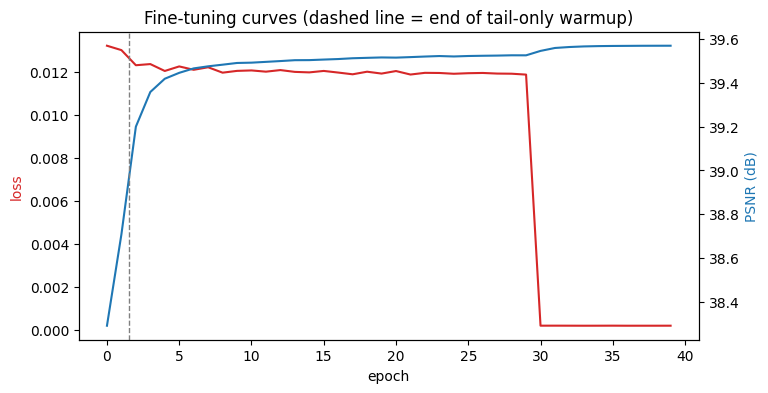

In [ ]:
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(history['train_loss'], label='train loss', color='tab:red')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss', color='tab:red')
ax2 = ax1.twinx()
ax2.plot(history['val_psnr'], label='EMA val PSNR', color='tab:blue')
ax2.axvline(WARMUP_EPOCHS - 0.5, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('PSNR (dB)', color='tab:blue')
plt.title('Fine-tuning curves (dashed line = end of tail-only warmup)')
plt.show()

In [ ]:
# push best checkpt to HF
from huggingface_hub import HfApi, create_repo

def push_to_hf(repo_id, token, file_path, path_in_repo=None):
    api = HfApi(token=token)
    create_repo(repo_id, token=token, exist_ok=True, repo_type='model')
    api.upload_file(
        path_or_fileobj=file_path,
        path_in_repo=path_in_repo or os.path.basename(file_path),
        repo_id=repo_id,
        repo_type='model',
        token=token,
    )
    print(f'Pushed {file_path} -> https://huggingface.co/{repo_id}')

if PUSH_TO_HF:
    push_to_hf(HF_REPO_ID, HF_TOKEN, BEST_CKPT)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Pushed /kaggle/working/checkpoints/best_model_v4_1.pth -> https://huggingface.co/somsubhra04/lowlight-denoise-sr4x


In [ ]:
#Inference: Inference: tiled + test-time augmentation (using EMA weights)
def load_model_for_inference(ckpt_path):
    m = RRDBNet(num_in_ch=3, num_out_ch=3, scale=SCALE, num_feat=64, num_block=23, num_grow_ch=32).to(DEVICE)
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    m.load_state_dict(ckpt['model_state'])   # EMA weights
    m.eval()
    print(f"loaded EMA checkpoint from epoch {ckpt['epoch']} (val PSNR {ckpt['val_psnr']:.3f} dB)")
    return m

infer_model = load_model_for_inference(BEST_CKPT)

@torch.no_grad()
def tiled_infer(model, lr_np, tile=160, overlap=16, scale=SCALE):
    h, w, _ = lr_np.shape
    if h <= tile and w <= tile:
        x = torch.from_numpy(lr_np).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
        with autocast():
            out = model(x).clamp(0, 1)
        return out[0].permute(1, 2, 0).cpu().numpy()

    out_h, out_w = h * scale, w * scale
    output = np.zeros((out_h, out_w, 3), dtype=np.float32)
    weight = np.zeros((out_h, out_w, 1), dtype=np.float32)

    stride = tile - overlap
    for y in range(0, h, stride):
        for x0 in range(0, w, stride):
            y1, x1 = min(y + tile, h), min(x0 + tile, w)
            y0, x_0 = max(0, y1 - tile), max(0, x1 - tile)
            patch = lr_np[y0:y1, x_0:x1]
            pt = torch.from_numpy(patch).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
            with autocast():
                pred = model(pt).clamp(0, 1)
            pred = pred[0].permute(1, 2, 0).cpu().numpy()

            oy0, oy1 = y0 * scale, y1 * scale
            ox0, ox1 = x_0 * scale, x1 * scale
            output[oy0:oy1, ox0:ox1] += pred
            weight[oy0:oy1, ox0:ox1] += 1.0

    return output / np.maximum(weight, 1e-8)

@torch.no_grad()
def tta_infer(model, lr_np, **kwargs):
    variants = [
        (lambda im: im, lambda im: im),
        (lambda im: np.fliplr(im), lambda im: np.fliplr(im)),
        (lambda im: np.flipud(im), lambda im: np.flipud(im)),
        (lambda im: np.rot90(im, 2), lambda im: np.rot90(im, 2)),
    ]
    preds = []
    for fwd, inv in variants:
        pred = tiled_infer(model, fwd(lr_np).copy(), **kwargs)
        preds.append(inv(pred))
    return np.mean(preds, axis=0)

loaded EMA checkpoint from epoch 39 (val PSNR 39.571 dB)


In [ ]:
#build submission file
def load_lr(path):
    return np.array(Image.open(path).convert('RGB'), dtype=np.float32) / 255.0

test_files = sorted([f for f in os.listdir(TEST_DIR)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))])
print('test images:', len(test_files))

canonical_hr_size = hr_sizes.most_common(1)[0][0]  # (W, H), guards against ragged CSV rows
print('canonical HR output size:', canonical_hr_size)

rows = []
for fname in test_files:
    lr_np = load_lr(os.path.join(TEST_DIR, fname))
    hr_pred = tta_infer(infer_model, lr_np, tile=160, overlap=16)
    hr_pred_u8 = np.clip(hr_pred * 255.0, 0, 255).astype(np.uint8)

    hr_img = Image.fromarray(hr_pred_u8)
    if hr_img.size != canonical_hr_size:
        hr_img = hr_img.resize(canonical_hr_size, Image.BICUBIC)

    gray = np.array(hr_img.convert('L')).flatten()[::8]

    image_id = fname.split('.')[0].replace('test_', 'gt_')
    rows.append([image_id, *gray])

col_names = ['ID'] + [f'pixel_{i}' for i in range(len(rows[0]) - 1)]
sub_df = pd.DataFrame(rows, columns=col_names)
sub_df.to_csv('/kaggle/working/submission.csv', index=False)
print('saved submission.csv', sub_df.shape)
sub_df.head()

test images: 60
canonical HR output size: (1024, 640)


/tmp/ipykernel_22/2885086210.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


saved submission.csv (60, 81921)


,ID,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_81910,pixel_81911,pixel_81912,pixel_81913,pixel_81914,pixel_81915,pixel_81916,pixel_81917,pixel_81918,pixel_81919
0,gt_00001,70,62,63,53,57,56,51,48,49,...,24,24,24,24,24,23,24,23,23,23
1,gt_00002,55,38,49,54,55,46,38,35,43,...,35,35,35,35,35,35,35,35,35,35
2,gt_00003,39,38,37,37,37,36,36,38,41,...,37,37,38,38,38,38,38,38,38,38
3,gt_00004,60,62,64,65,67,70,84,103,103,...,44,44,44,44,44,45,45,45,45,45
4,gt_00005,22,22,22,22,22,22,22,22,22,...,53,53,53,53,53,53,53,53,53,53


In [ ]:
# load both of my v4 and v4_1 checkpoints
'''def load_rrdb(filename):
    path = hf_hub_download(repo_id=HF_REPO_ID, filename=filename, token=HF_TOKEN or None)
    m = RRDBNet(num_in_ch=3, num_out_ch=3, scale=SCALE, num_feat=64, num_block=23, num_grow_ch=32).to(DEVICE)
    ckpt = torch.load(path, map_location=DEVICE)
    m.load_state_dict(ckpt['model_state'])
    m.eval()
    return m, ckpt.get('val_psnr', None)

model_a, psnr_a = load_rrdb("best_model_v4.pth")
model_b, psnr_b = load_rrdb("best_model_v4_1.pth")
print(f'v4 reported val PSNR: {psnr_a} | v4_1 reported val PSNR: {psnr_b}')

# evaluate both, and a range of blend weights, on the REAL held-out val set
def psnr_np(pred, target):
    mse = np.mean((pred - target) ** 2)
    return 10 * np.log10(1.0 / mse) if mse > 0 else 100.0

def load_rgb(path):
    return np.array(Image.open(path).convert('RGB'), dtype=np.float32) / 255.0

@torch.no_grad()
def infer_single(model, lr_np):
    x = torch.from_numpy(lr_np).permute(2,0,1).unsqueeze(0).float().to(DEVICE)
    with autocast():
        out = model(x).clamp(0, 1)
    return out[0].permute(1,2,0).float().cpu().numpy()

preds_a, preds_b, hrs = [], [], []
for i in val_ids:
    lr_np = load_rgb(val_lr_map[i]); hr_np = load_rgb(val_hr_map[i])
    preds_a.append(infer_single(model_a, lr_np))
    preds_b.append(infer_single(model_b, lr_np))
    hrs.append(hr_np)

def eval_blend(w):
    psnrs = [psnr_np(w * pa + (1 - w) * pb, hr) for pa, pb, hr in zip(preds_a, preds_b, hrs)]
    return np.mean(psnrs)

print(f'model A alone (w=1.0): {eval_blend(1.0):.3f} dB')
print(f'model B alone (w=0.0): {eval_blend(0.0):.3f} dB')
best_w, best_psnr_blend = None, -1
for w in np.arange(0.0, 1.01, 0.1):
    p = eval_blend(w)
    print(f'  w={w:.1f}: {p:.3f} dB')
    if p > best_psnr_blend:
        best_psnr_blend, best_w = p, w

print(f'\nbest blend: w={best_w:.1f} -> {best_psnr_blend:.3f} dB')'''

In [ ]:
hr_sizes = Counter()
for path in val_hr_map.values():
    with Image.open(path) as img:
        hr_sizes[img.size] += 1
canonical_hr_size = hr_sizes.most_common(1)[0][0]
print('Canonical HR output size (W, H):', canonical_hr_size)

# load both checkpoints
def load_rrdb(filename):
    path = hf_hub_download(repo_id=HF_REPO_ID, filename=filename, token=HF_TOKEN or None)
    m = RRDBNet(num_in_ch=3, num_out_ch=3, scale=SCALE, num_feat=64, num_block=23, num_grow_ch=32).to(DEVICE)
    ckpt = torch.load(path, map_location=DEVICE)
    m.load_state_dict(ckpt['model_state'])
    m.eval()
    return m

model_a = load_rrdb("best_model_v4.pth")
model_b = load_rrdb("best_model_v4_1.pth")
BLEND_W = 0.3   # from grid search beta-test

# NEW: ensemble + 8-way TTA, using torch.amp.autocast (not the deprecated torch.cuda.amp)
def tta_infer_tensor_ensemble(model_a, model_b, w, lr_tensor):
    preds = []
    for rot in [0, 1, 2, 3]:
        for flip in [False, True]:
            x = torch.rot90(lr_tensor, k=rot, dims=(2, 3))
            if flip:
                x = torch.flip(x, dims=[3])
            with torch.amp.autocast('cuda'):
                sr_a = model_a(x).clamp(0.0, 1.0)
                sr_b = model_b(x).clamp(0.0, 1.0)
                sr = w * sr_a + (1 - w) * sr_b
            if flip:
                sr = torch.flip(sr, dims=[3])
            sr = torch.rot90(sr, k=-rot, dims=(2, 3))
            preds.append(sr)
    return torch.stack(preds, dim=0).mean(dim=0)

class TestDataset(Dataset):
    def __init__(self, test_dir):
        self.files = sorted([
            os.path.join(test_dir, f) for f in os.listdir(test_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))
        ])
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        path = self.files[idx]
        img = np.array(Image.open(path).convert('RGB'), dtype=np.float32) / 255.0
        fname = os.path.basename(path)
        return torch.from_numpy(img).permute(2, 0, 1).float(), fname

test_ds = TestDataset(TEST_DIR)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)

print(f"Running ensemble + TTA inference on {len(test_ds)} test images (blend w={BLEND_W})...")
rows = []
with torch.no_grad():
    for lr_img, fname in test_loader:
        fname_str = fname[0]
        lr_img = lr_img.to(DEVICE)

        sr_img = tta_infer_tensor_ensemble(model_a, model_b, BLEND_W, lr_img)

        sr_np = (sr_img[0].cpu().permute(1, 2, 0).numpy() * 255.0).round().astype(np.uint8)

        hr_img = Image.fromarray(sr_np)
        if hr_img.size != canonical_hr_size:
            hr_img = hr_img.resize(canonical_hr_size, Image.BICUBIC)
        gray = np.array(hr_img.convert('L')).flatten()[::8]

        base_name = os.path.splitext(fname_str)[0]
        image_id = base_name.replace('test_', 'gt_')
        rows.append([image_id] + gray.tolist())

if rows:
    num_pixels = len(rows[0]) - 1
    col_names = ['ID'] + [f'pixel_{i}' for i in range(num_pixels)]
    sub_df = pd.DataFrame(rows, columns=col_names)
    sub_df.to_csv('/kaggle/working/submission.csv', index=False)
    print('saved submission.csv with shape:', sub_df.shape)
    print(sub_df.head())
else:
    print('No test images found.')